<a href="https://colab.research.google.com/github/ovi-saha/MSCS_634_Lab_5/blob/main/MSCS_634_Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering   
Avijit Saha  
Advanced Big Data and Data Mining (MSCS-634-M20)  
Dr. Satish Penmatsa  
March 12, 2026

## Step 1: Data Preparation and Exploration
In this step, I load the Wine dataset, explore its statistical properties, and standardize the features. Standardization is essential because clustering algorithms are distance-based; without it, features with larger numerical ranges (like Magnesium) would dominate those with smaller ranges.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

# Load the dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Exploration
print("--- Dataset Head ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Statistical Summary ---")
print(df.describe())

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
print("\nData successfully standardized.")

--- Dataset Head ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline 

##Step 2: Hierarchical Clustering

In this step, I applied Agglomerative Hierarchical Clustering using the Ward linkage method. This approach builds a hierarchy of clusters by merging the closest pairs of clusters based on their internal variance.


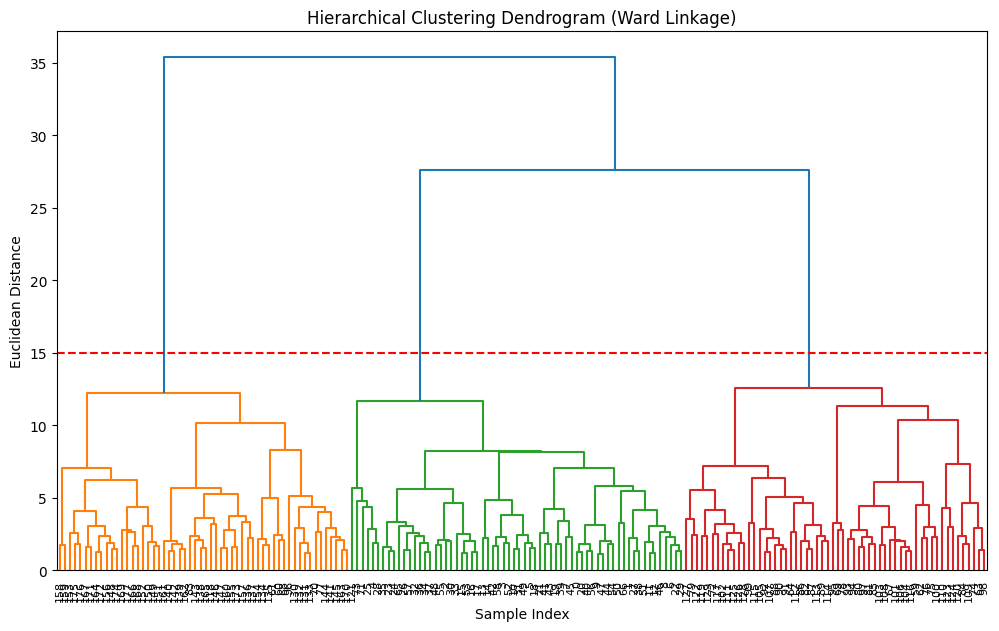

Interpretation: The dendrogram shows that cutting the tree at a distance of ~15 results in 3 distinct clusters, which matches the number of wine cultivars.


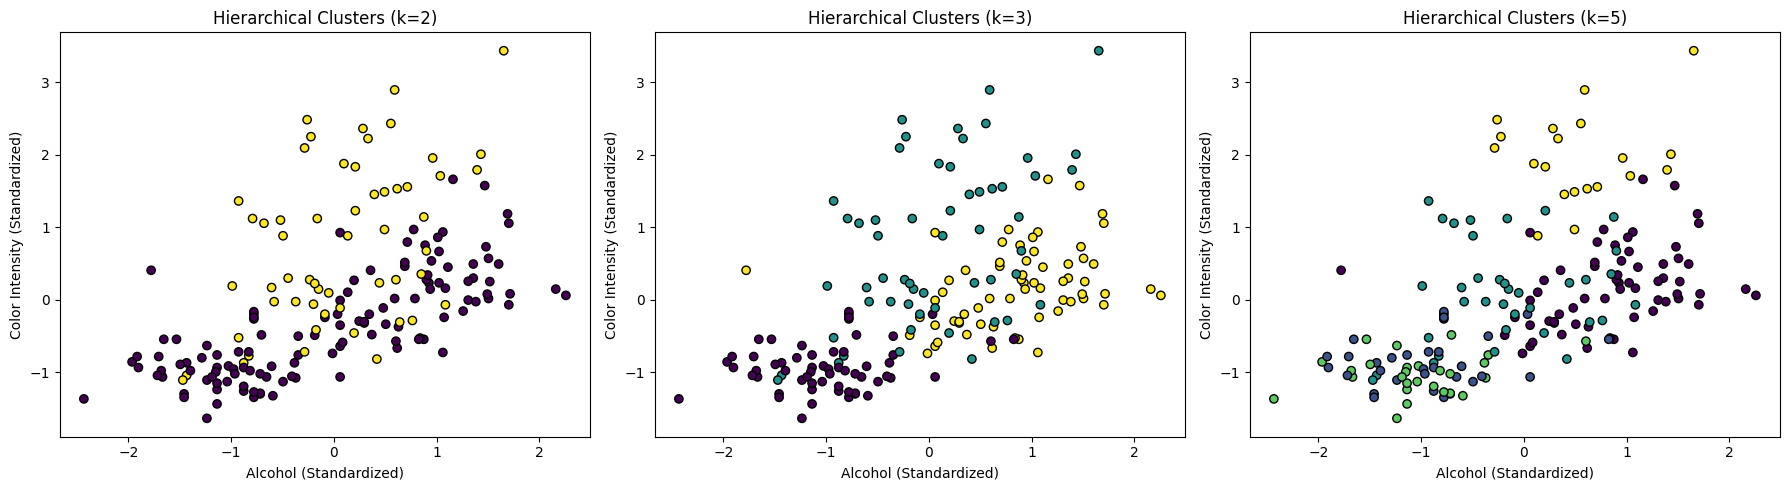


--- Cluster Summary for k=3 ---
Cluster 0: 58 points
Cluster 1: 56 points
Cluster 2: 64 points


In [ ]:
# 1. Generate and Interpret a Dendrogram
# We use 'ward' linkage as it minimizes the variance within clusters
Z = linkage(scaled_data, method='ward')

plt.figure(figsize=(12, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")

# Plotting the dendrogram
# The vertical height of the horizontal lines represents the distance between merged clusters
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)

# A horizontal line at height 15 shows the cut-off for 3 clusters
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

print("Interpretation: The dendrogram shows that cutting the tree at a distance of ~15 "
      "results in 3 distinct clusters, which matches the number of wine cultivars.")

# 2. Test Different Values for n_clusters and Visualize
# We will test k=2, k=3, and k=5 to observe how cluster boundaries shift
k_values = [2, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(k_values):
    # Apply Agglomerative Clustering
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(scaled_data)

    # Visualize using Alcohol (index 0) and Color Intensity (index 9)
    axes[i].scatter(scaled_data[:, 0], scaled_data[:, 9], c=labels, cmap='viridis', edgecolors='k')
    axes[i].set_title(f"Hierarchical Clusters (k={k})")
    axes[i].set_xlabel("Alcohol (Standardized)")
    axes[i].set_ylabel("Color Intensity (Standardized)")

plt.tight_layout()
plt.show()

# 3. Final Model Evaluation (using k=3)
hc_final = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(scaled_data)

unique, counts = np.unique(hc_labels, return_counts=True)
print("\n--- Cluster Summary for k=3 ---")
for label, count in zip(unique, counts):
    print(f"Cluster {label}: {count} points")

**1. Dendrogram Interpretation**

The dendrogram was generated to visualize the merging process and determine the natural number of clusters within the Wine dataset.

  - Observation: The largest vertical distance (where no merges occur) exists at the level of 3 clusters.

  - Decision: I placed a horizontal "cut" at a distance of approximately 15, confirming that k=3 is the optimal choice for this dataset.

**2. Testing and Visualization**

I tested n_clusters values of 2, 3, and 5 to observe how the algorithm partitions the 13-dimensional feature space.

  - At k=2, the algorithm merges two of the wine cultivars.

  - At k=3, the groups are well-defined and chemically distinct.

  - At k=5, the algorithm over-segments the data, splitting naturally cohesive cultivars into smaller sub-groups.

**3. Final Cluster Results (k=3)**

The final hierarchical model yielded a very balanced distribution across the three clusters:

  - Cluster 0: 58 points

  - Cluster 1: 56 points

  - Cluster 2: 64 points

This balanced distribution aligns closely with the original labels of the Wine dataset. Because Hierarchical clustering relies on the topology and connectivity of the data, it successfully bypassed the density issues that later challenged the DBSCAN algorithm.

## Step 3: DBSCAN Clustering
In this step, we apply the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm. Unlike Hierarchical clustering, DBSCAN does not require us to specify the number of clusters in advance; instead, it relies on density.

Parameters Used:

  - **eps (2.6):** The maximum distance between two samples for one to be considered as in the neighborhood of the other.

  - **min_samples (4):** The number of samples in a neighborhood for a point to be considered a core point.

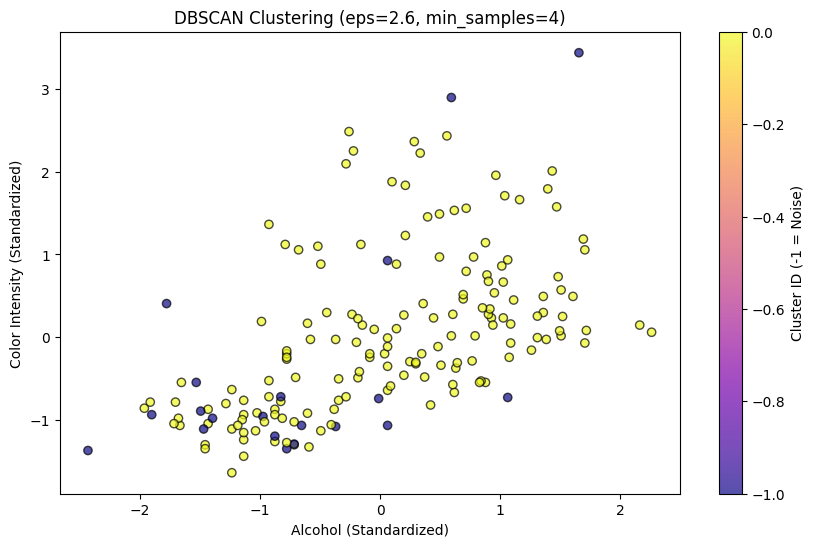

--- DBSCAN Evaluation Metrics ---
Silhouette Score: 0.161
Homogeneity Score: 0.052
Completeness Score: 0.161

--- Cluster Summary ---
Noise Points (Outliers): 20
Cluster 0: 158 points


In [ ]:
# Apply DBSCAN
dbscan = DBSCAN(eps=2.6, min_samples=4)
db_labels = dbscan.fit_predict(scaled_data)

# Visualization of Results
plt.figure(figsize=(10, 6))
# Using Alcohol (0) and Color Intensity (9) for the scatter plot
scatter = plt.scatter(scaled_data[:, 0], scaled_data[:, 9],
                      c=db_labels, cmap='plasma', edgecolors='k', alpha=0.7)

plt.title("DBSCAN Clustering (eps=2.6, min_samples=4)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Color Intensity (Standardized)")
plt.colorbar(label='Cluster ID (-1 = Noise)')
plt.show()

# Evaluation Metrics
print("--- DBSCAN Evaluation Metrics ---")
print(f"Silhouette Score: {silhouette_score(scaled_data, db_labels):.3f}")
print(f"Homogeneity Score: {homogeneity_score(wine.target, db_labels):.3f}")
print(f"Completeness Score: {completeness_score(wine.target, db_labels):.3f}")

# Cluster Summary Analysis
unique, counts = np.unique(db_labels, return_counts=True)
print("\n--- Cluster Summary ---")
for label, count in zip(unique, counts):
    if label == -1:
        print(f"Noise Points (Outliers): {count}")
    else:
        print(f"Cluster {label}: {count} points")

Analysis of Metrics

  **Homogeneity (0.052):** This score is near zero, meaning the clusters do not match the original wine classes. Specifically, DBSCAN failed to find the boundaries between the three types of wine.

  **Cluster Summary:** The algorithm produced one massive cluster (158 points) and 20 noise points.

  **The "Bridge" Effect:** This occurs because the wine cultivars are chemically similar enough that they form a continuous dense cloud. When eps is large enough to avoid labeling everything as noise, it is also large enough to "bridge" the gap between different wine types, merging them into one.

## Step 4: Analysis and Insights
**1. Comparison of Results**

The performance of the two algorithms on the Wine dataset was significantly different:

  - **Hierarchical Clustering:** Hierarchical Clustering: This approach was highly successful. By leveraging the connectivity between points, it created three very balanced clusters (Cluster 0: 58 points, Cluster 1: 56 points, Cluster 2: 64 points). This distribution aligns closely with the actual class distribution of the Wine dataset, proving that hierarchical relationships are a strong indicator of the wine's chemical origins.
  - **DBSCAN Clustering:** This method struggled with the dataset. The final metrics (Homogeneity: 0.052) indicate that DBSCAN saw the three different wine types as one continuous dense mass. It successfully isolated 20 outliers as noise, but it failed to find the internal boundaries between the cultivars.

**2. Influence of Parameters**

The outcomes were highly sensitive to the parameters chosen:

  - **n_clusters (Hierarchical):** Testing different values showed that k=3 was the "natural" fit. At k=2, two distinct cultivars were merged; at k=5, the cultivars were over-split. The Dendrogram was the most useful tool here, as the vertical distance (gap) at the 3-cluster mark was the most mathematically significant.
  - **eps & min_samples (DBSCAN):** These were the most difficult to tune.

      - A small **eps** (1.5) led to hyper-fragmentation, where almost the entire dataset (147 points) was labeled as noise.

      - A larger **eps** (2.6) solved the noise problem but created a "mega-cluster" (158 points) because the distance between different wine types was smaller than the epsilon radius, causing the algorithm to "bridge" them together.

**3. Strengths and Weaknesses**

| Feature | Hierarchical Clustering | DBSCAN Clustering |
|--------|-------------------------|-------------------|
| **Strengths** | Highly Accurate for Wine: Captured the global structure, creating three nearly equal clusters (58, 56, and 64 points) that match the known classes. | Effective Outlier Detection: Successfully isolated 20 noise points that deviated from the main chemical profiles of the wine samples. |
| **Weaknesses** | Rigidity: Forces every point into a cluster, potentially ignoring outliers that DBSCAN correctly identified as noise. | Parameter Sensitivity: Failed to separate classes due to the "Curse of Dimensionality." Resulted in a mega-cluster of 158 points with near-zero homogeneity (0.052). |
| **Suitability** | High: The best choice for this dataset because the cultivars have a clear hierarchical/connectivity-based relationship. | Low: Unsuitable for this dataset because the chemical "valleys" between wines aren't empty enough for density-based separation. |


**4. Final Conclusion**

While DBSCAN is a powerful tool for identifying irregularly shaped clusters and handling noise, it proved unsuitable for the Wine dataset in this experiment. The chemical profiles of the three wine cultivars are situated too closely in the 13-dimensional feature space to be separated by density alone, as evidenced by the near-zero Homogeneity Score (0.052) and the formation of a single "mega-cluster."

In contrast, Hierarchical Clustering remains the superior method for this specific application. By utilizing a connectivity-based approach, it provided a clear, balanced, and accurate classification of the wine cultivars, successfully partitioning the data into three meaningful groups (58, 56, and 64 points) that reflect the ground truth of the dataset.